Citations: Andrew Lucas: Ising formulations of many NP Problems. arXiv:1302.5843. 
https://arxiv.org/abs/1302.5843

Ising machine: 3-SAT (via reduction to MIS)

3-SAT asks: given a Boolean formula in conjunctive normal form with 3 literals
per clause, is there an assignment of variables that satisfies all clauses?

Lucas §4.4 reduces 3-SAT to Maximum Independent Set:
1. For each clause C_i with 3 literals, create 3 nodes (one per literal)
2. Connect all 3 nodes within each clause (triangle)
3. Connect any two nodes whose literals are complements (x and NOT x)
4. The formula is satisfiable iff the MIS on this graph has size m (num clauses)

We then solve MIS using the Set Packing Hamiltonian (Lucas §4.2):
- H_A = A * sum_{(ij) in E} x_i * x_j <- penalty term for selecting adjacent
  vertices for one subset
- H_B = -B * sum_i x_i <- penalty term for selecting fewer vertices for a subset

This problem is NP-complete, so we should get H = 0 or != 0 if a solution
does/doesn't exist.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
# ---- 3-SAT to MIS Reduction (Lucas §4.4) ----

def sat3_to_graph(num_vars, clauses):
    """
    Convert a 3-SAT instance to an MIS graph.
    
    num_vars: number of Boolean variables (x1, x2, ..., x_n)
    clauses: list of clauses, each clause is a tuple of 3 integers.
             positive int = variable, negative int = NOT variable.
             e.g. (1, -2, 3) means (x1 OR NOT x2 OR x3)
    
    Returns:
        adjacency_matrix: NxN matrix for the MIS graph (N = 3 * num_clauses)
        node_labels: list of (clause_index, literal) for each node
    """
    m = len(clauses)
    N = 3 * m  # 3 nodes per clause
    adjacency_matrix = np.zeros((N, N), dtype=np.int64)
    node_labels = []

    # create node labels
    for i, clause in enumerate(clauses):
        for lit in clause:
            node_labels.append((i, lit))

    # add edges within each clause (triangle)
    for i in range(m):
        base = 3 * i
        for a in range(3):
            for b in range(a + 1, 3):
                adjacency_matrix[base + a, base + b] = 1
                adjacency_matrix[base + b, base + a] = 1

    # add edges between complementary literals across clauses
    for i in range(N):
        for j in range(i + 1, N):
            ci, li = node_labels[i]
            cj, lj = node_labels[j]
            # only connect across different clauses
            if ci != cj and li == -lj:
                adjacency_matrix[i, j] = 1
                adjacency_matrix[j, i] = 1

    return adjacency_matrix, node_labels

In [3]:
# ---- Hamiltonian Penalty Terms ----
def get_ha(adjacency_matrix, xalpha, A):
    N = len(xalpha)
    ha = 0
    for i in range(N):
        for j in range(i + 1, N):
            if adjacency_matrix[i, j] == 1:
                ha += xalpha[i] * xalpha[j]
    return A * ha

def get_hb(xalpha, B):
    return -B * np.sum(xalpha)

def calc_energy(adjacency_matrix, xalpha, A, B):
    return get_ha(adjacency_matrix, xalpha, A) + get_hb(xalpha, B)

In [4]:

def annealing(adjacency_matrix, xalpha, A, B, T_start, steps):
    N = len(xalpha)
    xalpha = xalpha.copy()
    energy = calc_energy(adjacency_matrix, xalpha, A, B)
    best_xalpha = xalpha.copy()
    best_energy = energy

    for step in range(steps):
        j = np.random.randint(0, N)
        xalpha[j] = 1 - xalpha[j]
        new_energy = calc_energy(adjacency_matrix, xalpha, A, B)
        delta_energy = new_energy - energy

        T = T_start / (1 + step * 0.001)
        if delta_energy < 0 or np.random.rand() < np.exp(-delta_energy / T):
            energy = new_energy
            if energy < best_energy:
                best_energy = energy
                best_xalpha = xalpha.copy()
        else:
            xalpha[j] = 1 - xalpha[j]

    return best_xalpha, best_energy

In [5]:
# ---- Extract SAT assignment from MIS solution ----

def extract_assignment(xalpha, node_labels, num_vars):
    """
    Extract a Boolean variable assignment from the MIS solution.
    Selected nodes tell us which literal in each clause is true.
    """
    assignment = {}
    for i, val in enumerate(xalpha):
        if val == 1:
            clause_idx, literal = node_labels[i]
            var = abs(literal)
            truth_val = literal > 0
            if var not in assignment:
                assignment[var] = truth_val
    # fill in unassigned variables arbitrarily
    for v in range(1, num_vars + 1):
        if v not in assignment:
            assignment[v] = True
    return assignment

def verify_sat(clauses, assignment):
    """Check if an assignment satisfies all clauses."""
    for i, clause in enumerate(clauses):
        satisfied = False
        for lit in clause:
            var = abs(lit)
            if lit > 0 and assignment[var]:
                satisfied = True
            elif lit < 0 and not assignment[var]:
                satisfied = True
        if not satisfied:
            print(f"UNSATISFIED clause {i}: {clause}")
            return False
    print("ALL CLAUSES SATISFIED")
    return True

In [6]:


def plot_sat_graph(adjacency_matrix, node_labels, xalpha):
    N = adjacency_matrix.shape[0]
    G = nx.from_numpy_array(adjacency_matrix)

    # group nodes by clause for layout
    m = len(set(cl for cl, _ in node_labels))
    pos = {}
    for i in range(m):
        cx, cy = np.cos(2 * np.pi * i / m), np.sin(2 * np.pi * i / m)
        for k in range(3):
            node = 3 * i + k
            offset_x = 0.15 * np.cos(2 * np.pi * k / 3)
            offset_y = 0.15 * np.sin(2 * np.pi * k / 3)
            pos[node] = (cx + offset_x, cy + offset_y)

    colours = ['red' if xalpha[i] == 1 else 'lightblue' for i in range(N)]

    # edge colours: gray for intra-clause, orange for complement edges
    edge_colours = []
    for u, v in G.edges():
        cu, _ = node_labels[u]
        cv, _ = node_labels[v]
        edge_colours.append('gray' if cu == cv else 'orange')

    # node labels show the literal
    labels = {}
    for i, (ci, lit) in enumerate(node_labels):
        var = abs(lit)
        labels[i] = f"x{var}" if lit > 0 else f"~x{var}"

    plt.figure(figsize=(8, 8))
    nx.draw_networkx_edges(G, pos, edge_color=edge_colours, width=1.5)
    nx.draw_networkx_nodes(G, pos, node_color=colours, node_size=500)
    nx.draw_networkx_labels(G, pos, labels, font_size=9)

    selected_count = sum(xalpha)
    plt.title(f"3-SAT → MIS graph ({m} clauses, MIS size {selected_count})")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [7]:
# ---- Define a 3-SAT instance ----
# (x1 OR NOT x2 OR x3) AND (NOT x1 OR x2 OR x4) AND (x2 OR NOT x3 OR NOT x4)

num_vars = 4
clauses = [
    (1, -2, 3),
    (-1, 2, 4),
    (2, -3, -4),
]

print("3-SAT instance:")
for i, clause in enumerate(clauses):
    lits = []
    for lit in clause:
        lits.append(f"x{abs(lit)}" if lit > 0 else f"~x{abs(lit)}")
    print(f"  C{i+1}: ({' OR '.join(lits)})")

3-SAT instance:
  C1: (x1 OR ~x2 OR x3)
  C2: (~x1 OR x2 OR x4)
  C3: (x2 OR ~x3 OR ~x4)


MIS size found: 3 (need 3 for SAT to be satisfiable)
Energy: -3.0
H_A (should be 0): 0.0

SATISFIABLE
Assignment: {3: True, 1: False, 2: True, 4: True}
ALL CLAUSES SATISFIED


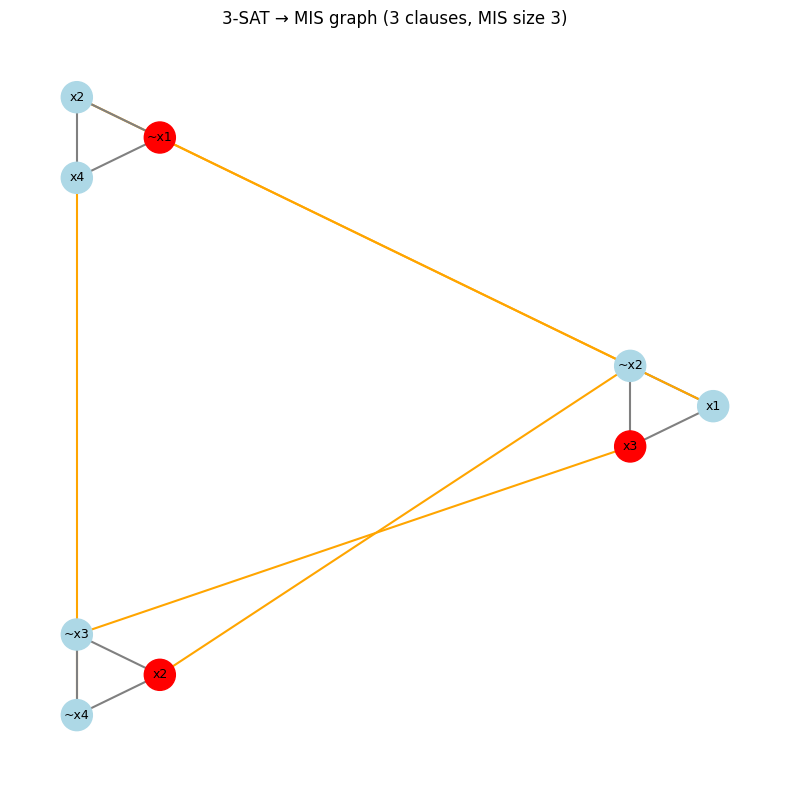

In [8]:
# ---- Convert to MIS graph and solve ----

adjacency_matrix, node_labels = sat3_to_graph(num_vars, clauses)
m = len(clauses)
N = 3 * m

A = 2.0
B = 1.0
T_start = 5.0
steps = 500000

xalpha = np.random.randint(2, size=N)
best_xalpha, best_energy = annealing(adjacency_matrix, xalpha, A, B, T_start, steps)

selected_count = int(np.sum(best_xalpha))
print(f"MIS size found: {selected_count} (need {m} for SAT to be satisfiable)")
print(f"Energy: {best_energy}")
print(f"H_A (should be 0): {get_ha(adjacency_matrix, best_xalpha, A)}")

if selected_count == m and get_ha(adjacency_matrix, best_xalpha, A) == 0:
    print("\nSATISFIABLE")
    assignment = extract_assignment(best_xalpha, node_labels, num_vars)
    print(f"Assignment: {assignment}")
    verify_sat(clauses, assignment)
else:
    print("\nNo satisfying assignment found (try more steps or retries)")

plot_sat_graph(adjacency_matrix, node_labels, best_xalpha)

Random 3-SAT: 6 variables, 8 clauses
  C1: (x6 OR ~x2 OR ~x1)
  C2: (~x3 OR x2 OR ~x6)
  C3: (~x4 OR ~x2 OR ~x3)
  C4: (x3 OR ~x2 OR x4)
  C5: (~x3 OR x2 OR x6)
  C6: (x5 OR x6 OR ~x2)
  C7: (x3 OR ~x1 OR x6)
  C8: (x6 OR x3 OR x5)

MIS size found: 8 (need 8 for SAT)
SATISFIABLE
Assignment: {6: True, 3: False, 4: True, 2: False, 5: True, 1: True}
ALL CLAUSES SATISFIED


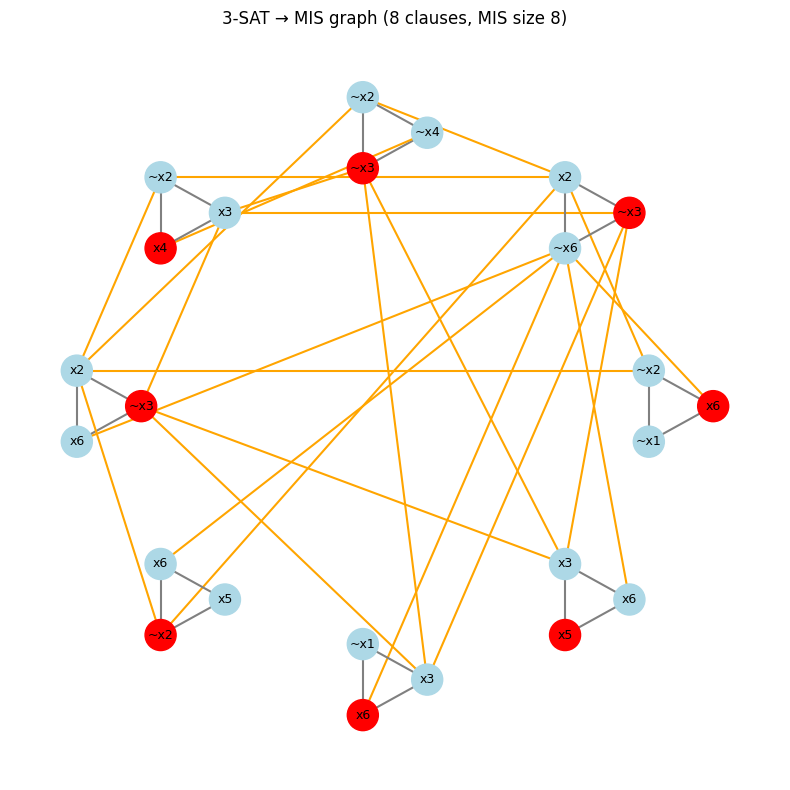

In [9]:
# ---- Larger random 3-SAT instance ----

def generate_random_3sat(num_vars, num_clauses):
    clauses = []
    for _ in range(num_clauses):
        vars_chosen = np.random.choice(range(1, num_vars + 1), size=3, replace=False)
        signs = np.random.choice([-1, 1], size=3)
        clause = tuple(int(v * s) for v, s in zip(vars_chosen, signs))
        clauses.append(clause)
    return clauses

num_vars = 6
num_clauses = 8
clauses = generate_random_3sat(num_vars, num_clauses)

print(f"Random 3-SAT: {num_vars} variables, {num_clauses} clauses")
for i, clause in enumerate(clauses):
    lits = [f"x{abs(l)}" if l > 0 else f"~x{abs(l)}" for l in clause]
    print(f"  C{i+1}: ({' OR '.join(lits)})")

adjacency_matrix, node_labels = sat3_to_graph(num_vars, clauses)
N = 3 * num_clauses

xalpha = np.random.randint(2, size=N)
best_xalpha, best_energy = annealing(adjacency_matrix, xalpha, A, B, T_start, steps=1000000)

selected_count = int(np.sum(best_xalpha))
print(f"\nMIS size found: {selected_count} (need {num_clauses} for SAT)")

if selected_count == num_clauses and get_ha(adjacency_matrix, best_xalpha, A) == 0:
    print("SATISFIABLE")
    assignment = extract_assignment(best_xalpha, node_labels, num_vars)
    print(f"Assignment: {assignment}")
    verify_sat(clauses, assignment)
else:
    print("No satisfying assignment found (may be UNSAT or need more steps)")

plot_sat_graph(adjacency_matrix, node_labels, best_xalpha)